## The Law of Large Numbers
- This is the idea that underwrites our faith in "large $n$" analysis
- If you are the kind of person who says they "do not like math" or "are not good at math", that's OK, this isn't on a test

## Independent and Identically Distributed Sequences (iid)
- A fundamental concept in probability and statistics is the abstract idea of running an "experiment" over and over, and computing statistics for the results
- Let $x_1$ be the result of the first experiment, $x_2$ the result of the second, and so on
- Assume that the draws $x_1, x_2, ...$ 
  - are **identically distributed**: They are all drawn from the same distribution function and all have the same mean $\mu$ and variance $\sigma^2$
  - are **independent**: The outcome of draw $x_n$ doesn't affect the outcome of any draw $x_m$, $m \neq n$


## Independent and Identically Distributed Sequences (iid)
- The sample average and sample variance are now, themselves, random variables, with their own outcomes, events, probabilities, and so on
- The **sample average** of our experimental sequence is
$$
\bar{X}_n = \dfrac{1}{n} \sum_{i=1}^n x_i
$$
and the **sample variance** of our experimental sequence is
$$
\bar{s}_n^2 = \dfrac{1}{n} \sum_{i=1}^n (x_i - \bar{X}_n)^2
$$

## Sample Mean of an IID Sequence
- What is the expected value of $\bar{X}_n$?
$$
\begin{alignat*}{2}
\mathbb{E}[\bar{X}_n] &=& \mathbb{E}\left[ \dfrac{1}{n} \left( X_1 + X_2 + ... + X_n \right) \right] \\
&=& \dfrac{\mathbb{E}[X_1] + ... + \mathbb{E}[X_n]}{n} \\
&=& \dfrac{\mu + ... + \mu}{n} \\
&=& \dfrac{n\mu}{n} \\
&=& \mu
\end{alignat*}
$$


## Sample Variance of an IID Sequence
- Likewise (but slightly different steps)
$$
\begin{alignat*}{2}
\mathbb{V}[\bar{X}_n] &=& \mathbb{V}\left[\frac{1}{n}(X_1 + X_2 + ... + X_n)\right] \\
&=& \frac{1}{n^2} \mathbb{V}[X_1 + X_2 + ... + X_n] \\
&=& \frac{1}{n^2} \left( \mathbb{V}[X_1] + \mathbb{V}[X_2] + ... + \mathbb{V}[X_n] \right) \\
&=& \frac{n}{n^2} \sigma^2 \\
&=& \frac{\sigma^2}{n}
\end{alignat*}
$$
- To emphasize that the sample space of $S_n$ depends on the sequence $n$, we'll write the probability function as $p_n$

## The Question

- What is the probability that the sample mean $\bar{X}_n$ is more than $d$-far away from its mean, $\mathbb{E}[X]$?
- In symbols, $p[ |\bar{X}_n - \mathbb{E}[X] | > d ]$?
- The key trick is to notice two things:
    1. Since $|\bar{X}_n - \mu| = \sqrt{(\bar{X}_n - \mu)^2}$, the original probability is the same as $\text{pr}[ (\bar{X}_n - \mu)^2 > d^2]$
    2. $(\bar{X}_n-\mu)^2$ in the above terms is very similar to the variance, $\mathbb{E}[ (\bar{X}_n - \mu)^2]$

## The Markov-Chebyshev Inequality
- Suppose that $R(x_i) \ge 0$, so all the random variable only takes non-negative values
- Pick a value $a$ that is between $x_1$ and $x_N$. What can we say about the relationship between $p$, $\sigma^2$, and $d$?
\begin{alignat*}{2}
\mathbb{E}[(\bar{X}_n-\mu)^2] &=& \sum_{(\bar{X}_n-\mu)^2 < d^2} p(\bar{X}_n) (\bar{X}_n-\mu)^2 + \sum_{(\bar{X}_n-\mu)^2 \ge d^2} p(\bar{X}_n) (\bar{X}_n-\mu)^2 \\
& \ge & \sum_{(\bar{X}_n-\mu)^2 < d^2} p(\bar{X}_n) 0 + \sum_{(\bar{X}_n-\mu)^2 \ge d^2} p(\bar{X}_n) (\bar{X}_n-\mu)^2 \\
& \ge & \sum_{ (\bar{X}_n-\mu)^2 \ge d^2} p(\bar{X}_n) d^2 \\
\mathbb{V}[\bar{X}_n] & \ge & p[(\bar{X}_n-\mu)^2 \ge d^2] d^2
\end{alignat*}
- This implies that
$$
p[ |\bar{X}_n-\mu| \ge d] \le \dfrac{\sigma^2}{nd^2}
$$
- **As $n$ gets large on the right, $\frac{\sigma^2}{nd^2}$ goes to zero, for any $d$.**

## The Weak Law of Large Numbers
- If $X_i$ is an IID sequence where each draw has the same mean $\mu$ and variance $\sigma^2$, then 
$$
p\left[ |\bar{X}_n - \mu|  \ge d \right] \le \dfrac{\mathbb{V}[\bar{X}_n]}{d^2} = \dfrac{\sigma^2}{n d^2},
$$
and **$\bar{X}_n$ converges to $\mu$ in probability**.

## Three Simulation Examples

The formal result above says two things at once:

1. The sample mean is centered at the population mean: $\mathbb{E}[\bar{X}_n] = \mu$.
2. The sample mean gets less noisy as $n$ grows: $\mathbb{V}[\bar{X}_n] = \sigma^2/n$.

The next examples use simulation to make both claims visible. Each simulation creates a matrix where rows are repeated samples and columns are observations inside each sample. This lets us look in two directions:

- Across a row: one sample mean settles down as $n$ grows.
- Down a column of repeated sample means: the sampling distribution of $\bar{X}_n$ stays centered at $\mu$ but tightens as $n$ grows.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.style.use("seaborn-v0_8-whitegrid")


## Example 1: Bernoulli Draws

Let $X_i \sim \text{Bernoulli}(p)$ with a fixed, known value of $p$.

For a Bernoulli random variable,

$$
\mathbb{E}[X_i] = p
$$

and

$$
\mathbb{V}[X_i] = p(1-p).
$$

So the sample mean should satisfy

$$
\mathbb{E}[\bar{X}_n] = p
$$

and

$$
\mathbb{V}[\bar{X}_n] = \dfrac{p(1-p)}{n}.
$$

The code below checks both claims by simulation.


,n,simulated E[Xbar_n],formal E[Xbar_n],simulated V[Xbar_n],formal V[Xbar_n]
0,5,0.349360,0.35,0.046005,0.045500
1,10,0.349900,0.35,0.022805,0.022750
2,25,0.350648,0.35,0.009198,0.009100
3,50,0.348864,0.35,0.004478,0.004550
4,100,0.349338,0.35,0.002222,0.002275
5,250,0.349919,0.35,0.000910,0.000910
6,500,0.350057,0.35,0.000472,0.000455


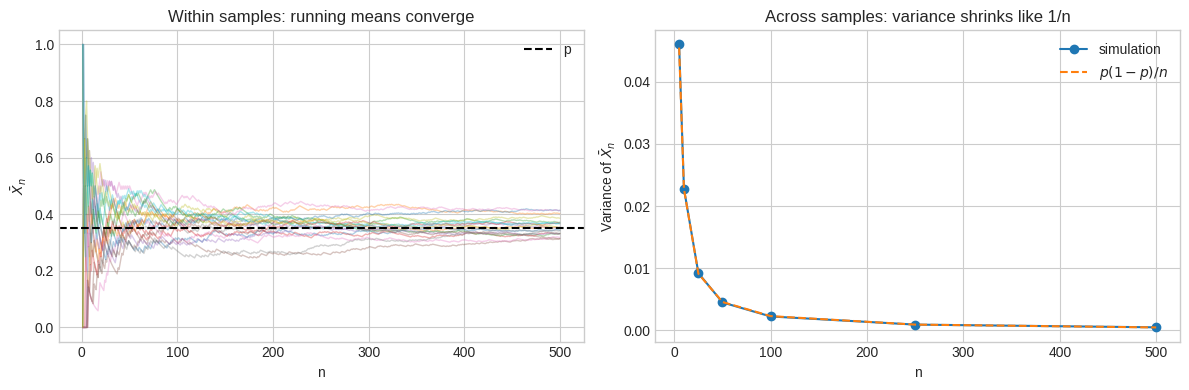

In [2]:
p = 0.35
repetitions = 5_000
n_max = 500
n_grid = np.array([5, 10, 25, 50, 100, 250, 500])

# Each row is one simulated sample. Each column is another Bernoulli draw.
bernoulli_draws = rng.binomial(1, p, size=(repetitions, n_max))

# Running sample means within each row: Xbar_1, Xbar_2, ..., Xbar_nmax.
bernoulli_running_means = bernoulli_draws.cumsum(axis=1) / np.arange(1, n_max + 1)

# For each n in n_grid, look down the rows at many repeated values of Xbar_n.
bernoulli_xbar = bernoulli_running_means[:, n_grid - 1]

bernoulli_summary = pd.DataFrame({
    "n": n_grid,
    "simulated E[Xbar_n]": bernoulli_xbar.mean(axis=0),
    "formal E[Xbar_n]": p,
    "simulated V[Xbar_n]": bernoulli_xbar.var(axis=0, ddof=1),
    "formal V[Xbar_n]": p * (1 - p) / n_grid,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for row in range(20):
    axes[0].plot(
        np.arange(1, n_max + 1),
        bernoulli_running_means[row],
        alpha=0.35,
        linewidth=1,
    )
axes[0].axhline(p, color="black", linestyle="--", label="p")
axes[0].set_title("Within samples: running means converge")
axes[0].set_xlabel("n")
axes[0].set_ylabel(r"$\bar{X}_n$")
axes[0].legend()

axes[1].plot(n_grid, bernoulli_summary["simulated V[Xbar_n]"], "o-", label="simulation")
axes[1].plot(n_grid, bernoulli_summary["formal V[Xbar_n]"], "--", label=r"$p(1-p)/n$")
axes[1].set_title("Across samples: variance shrinks like 1/n")
axes[1].set_xlabel("n")
axes[1].set_ylabel(r"Variance of $\bar{X}_n$")
axes[1].legend()

plt.tight_layout()
bernoulli_summary


## Example 2: Exponential Draws

Now let $X_i \sim \text{Exponential}(\lambda)$, where $\lambda$ is the rate.

For an exponential random variable,

$$
\mathbb{E}[X_i] = \dfrac{1}{\lambda}
$$

and

$$
\mathbb{V}[X_i] = \dfrac{1}{\lambda^2}.
$$

So the sample mean should satisfy

$$
\mathbb{E}[\bar{X}_n] = \dfrac{1}{\lambda}
$$

and

$$
\mathbb{V}[\bar{X}_n] = \dfrac{1}{\lambda^2 n}.
$$

The exponential distribution is more spread out and right-skewed than a Bernoulli distribution, but the same LLN logic applies.


,n,simulated E[Xbar_n],formal E[Xbar_n],simulated V[Xbar_n],formal V[Xbar_n]
0,5,0.502647,0.5,0.049994,0.0500
1,10,0.499831,0.5,0.026087,0.0250
2,25,0.501019,0.5,0.010411,0.0100
3,50,0.500920,0.5,0.005317,0.0050
4,100,0.499787,0.5,0.002611,0.0025
5,250,0.499565,0.5,0.001021,0.0010
6,500,0.499942,0.5,0.000512,0.0005


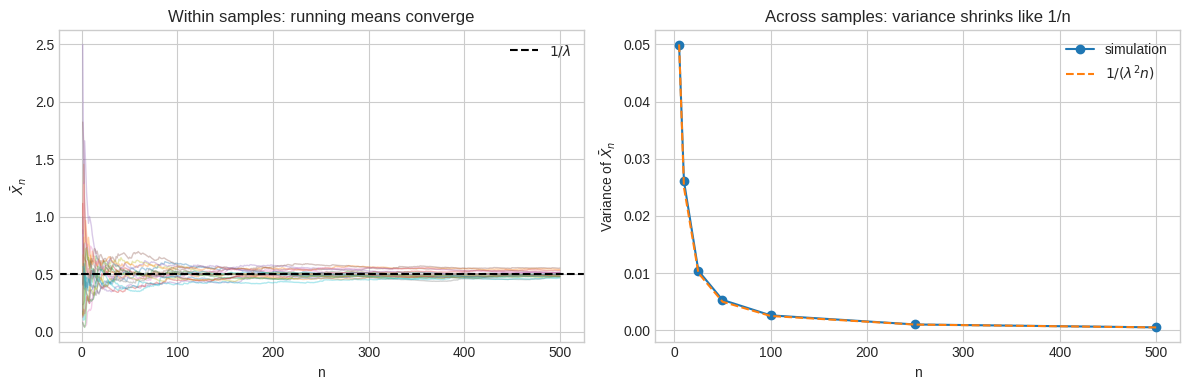

In [3]:
rate = 2
mu = 1 / rate
sigma_squared = 1 / rate**2

repetitions = 5_000
n_max = 500
n_grid = np.array([5, 10, 25, 50, 100, 250, 500])

# NumPy uses scale = mean = 1/rate for exponential draws.
exponential_draws = rng.exponential(scale=mu, size=(repetitions, n_max))
exponential_running_means = exponential_draws.cumsum(axis=1) / np.arange(1, n_max + 1)
exponential_xbar = exponential_running_means[:, n_grid - 1]

exponential_summary = pd.DataFrame({
    "n": n_grid,
    "simulated E[Xbar_n]": exponential_xbar.mean(axis=0),
    "formal E[Xbar_n]": mu,
    "simulated V[Xbar_n]": exponential_xbar.var(axis=0, ddof=1),
    "formal V[Xbar_n]": sigma_squared / n_grid,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for row in range(20):
    axes[0].plot(
        np.arange(1, n_max + 1),
        exponential_running_means[row],
        alpha=0.35,
        linewidth=1,
    )
axes[0].axhline(mu, color="black", linestyle="--", label=r"$1/\lambda$")
axes[0].set_title("Within samples: running means converge")
axes[0].set_xlabel("n")
axes[0].set_ylabel(r"$\bar{X}_n$")
axes[0].legend()

axes[1].plot(n_grid, exponential_summary["simulated V[Xbar_n]"], "o-", label="simulation")
axes[1].plot(n_grid, exponential_summary["formal V[Xbar_n]"], "--", label=r"$1/(\lambda^2 n)$")
axes[1].set_title("Across samples: variance shrinks like 1/n")
axes[1].set_xlabel("n")
axes[1].set_ylabel(r"Variance of $\bar{X}_n$")
axes[1].legend()

plt.tight_layout()
exponential_summary


## Example 3: Regression

Regression is a little different because the fitted coefficients are not just simple averages of the outcome variable. But they are built out of sample averages: averages of $x$, $y$, $x^2$, and $xy$.

For a simple linear regression,

$$
Y_i = \beta_0 + \beta_1 X_i + \epsilon_i,
$$

we can estimate $\beta_0$ and $\beta_1$ from sample moments. As $n$ grows, those sample moments stabilize, so the fitted coefficients should also stabilize.

The theory takes more work than the LLN by itself, but the LLN gives the right intuition: repeated regression estimates stay centered near the truth and become less variable as the sample size grows.


,n,coefficient,true value,average estimate,variance of estimate
0,20,intercept,1,0.996855,0.199326
1,20,slope,3,2.998134,0.229611
2,50,intercept,1,1.004488,0.084322
3,50,slope,3,2.993745,0.087256
4,100,intercept,1,0.995658,0.040826
5,100,slope,3,2.996171,0.042798
6,250,intercept,1,1.002792,0.015447
7,250,slope,3,3.000487,0.016119
8,500,intercept,1,0.994796,0.007852
9,500,slope,3,3.003501,0.008240


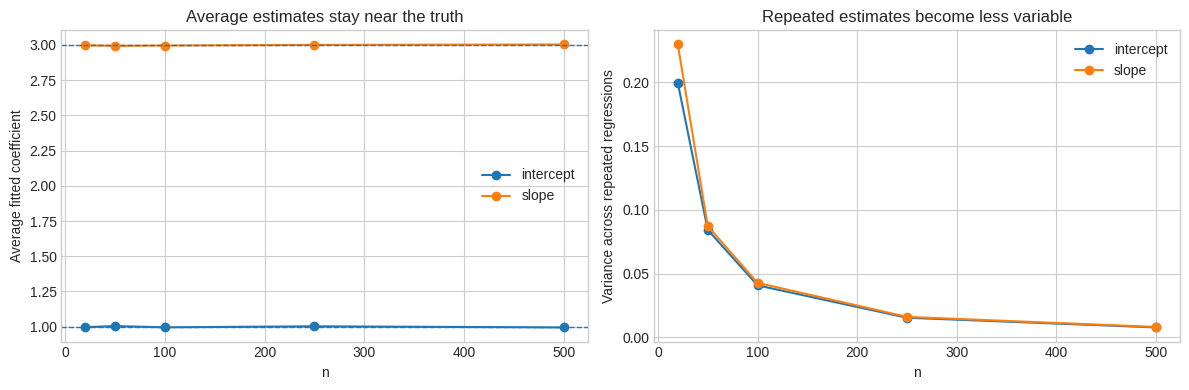

In [4]:
beta_0 = 1
beta_1 = 3
noise_sd = 2
repetitions = 2_000
n_grid = np.array([20, 50, 100, 250, 500])

regression_results = []

for n in n_grid:
    estimates = np.empty((repetitions, 2))
    moment_rows = []

    for r in range(repetitions):
        x = rng.normal(loc=0, scale=1, size=n)
        noise = rng.normal(loc=0, scale=noise_sd, size=n)
        y = beta_0 + beta_1 * x + noise

        X = np.column_stack([np.ones(n), x])
        estimates[r] = np.linalg.lstsq(X, y, rcond=None)[0]

        if r < 5:
            moment_rows.append({
                "n": n,
                "replication": r,
                "mean(x)": x.mean(),
                "mean(y)": y.mean(),
                "mean(x^2)": (x**2).mean(),
                "mean(xy)": (x * y).mean(),
            })

    regression_results.append(pd.DataFrame({
        "n": n,
        "coefficient": ["intercept", "slope"],
        "true value": [beta_0, beta_1],
        "average estimate": estimates.mean(axis=0),
        "variance of estimate": estimates.var(axis=0, ddof=1),
    }))

regression_summary = pd.concat(regression_results, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for coefficient, group in regression_summary.groupby("coefficient"):
    axes[0].plot(group["n"], group["average estimate"], "o-", label=coefficient)
    true_value = group["true value"].iloc[0]
    axes[0].axhline(true_value, linestyle="--", linewidth=1)

axes[0].set_title("Average estimates stay near the truth")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Average fitted coefficient")
axes[0].legend()

for coefficient, group in regression_summary.groupby("coefficient"):
    axes[1].plot(group["n"], group["variance of estimate"], "o-", label=coefficient)

axes[1].set_title("Repeated estimates become less variable")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Variance across repeated regressions")
axes[1].legend()

plt.tight_layout()
regression_summary
